In [15]:
import duckdb
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt



con = duckdb.connect('../capillary.db')

df = con.execute("""
                SELECT id,
                    any_value(pid) as pid, 
                    any_value(value) as value,
                    any_value(albumin) as albumin,
                    list(c.comment_nr) as comment_nr,
                    any_value(sign) as sign,
                    any_value(set) as set
                FROM protein_data p
                LEFT JOIN comment_precences c 
                    ON p.id = c.row_id
                GROUP BY id
                 """).df()


con.close()

def to_severity(comments: list[int]):
    max_found = 0
    for comment in comments:
        result = map_severity(comment)
        if result > max_found:
            max_found = result
    return max_found
        

def map_severity(label: int) -> int:        
    severity = 0
    match label:
        case 8:
            severity = 1 #Hypoalbuminemi
        case 9:
            severity = 2 #Påtaglig hypoalbuminemi
        case 10:
            severity = 3 #Grav hypoalbuminemi
        case _:
            severity = 0
    return severity

def to_coral(label: int, num_classes: int = 4):
    severity = to_severity(label)
    new_label = []
    for i in range(num_classes-1):
        if severity > i:
            new_label.append(1)
        else:
            new_label.append(0)
    return new_label



df['label'] = df['comment_nr'].apply(to_coral)
df['severity'] = df['comment_nr'].apply(to_severity)
df = df.set_index('id')

In [16]:
severity_range = [0,1,2,3]

most_frequent = 0
position_weights = []

for i in severity_range:
    no_occurences = (df['severity'] == i).sum()
    print(f"Antal fall med klass {i}:{no_occurences}")
    if no_occurences > most_frequent:
        most_frequent=no_occurences

for i in severity_range:
    no_occurences = (df['severity'] == i).sum()
    position_weights.append( most_frequent/no_occurences) 

df['frisk'] = df['label'].apply(lambda x: x[0] == 0)


df['hypoalmbuminemi'] = (df['severity'] == 1).astype(int)
df['påtaglig_hypoalbuminemi'] = (df['severity'] == 2).astype(int)
df['grav_hypoalbuminemi'] = (df['severity'] == 3).astype(int)


Antal fall med klass 0:155734
Antal fall med klass 1:8931
Antal fall med klass 2:5722
Antal fall med klass 3:2124


In [19]:

train_rows = df[df['set'] == 'train']
val_rows = df[df['set'] == 'val']
test_rows = df[df['set'] == 'test']

print(f"Antal fall med albuminavvikelse i träningsdatan:{(train_rows['severity'] != 0).sum()}")
print(f"Antal fall utan albuminavvikelse i träningsdatan:{(train_rows['severity'] == 0).sum()}")
print(f"Antal fall med albuminavvikelse i testdatan:{(test_rows['severity'] != 0).sum()}")
print(f"Antal fall utan albuminavvikelse i testdatan:{(test_rows['severity'] == 0).sum()}")


Antal fall med albuminavvikelse i träningsdatan:14432
Antal fall utan albuminavvikelse i träningsdatan:133253
Antal fall med albuminavvikelse i testdatan:1663
Antal fall utan albuminavvikelse i testdatan:15588


(array([   5.,    2.,    5.,   17.,   30.,   31.,   34.,   44.,   70.,
          70.,   86.,  113.,  158.,  216., 1618., 1330., 1864., 1527.,
         444.]),
 array([15.        , 16.05263158, 17.10526316, 18.15789474, 19.21052632,
        20.26315789, 21.31578947, 22.36842105, 23.42105263, 24.47368421,
        25.52631579, 26.57894737, 27.63157895, 28.68421053, 29.73684211,
        30.78947368, 31.84210526, 32.89473684, 33.94736842, 35.        ]),
 <BarContainer object of 19 artists>)

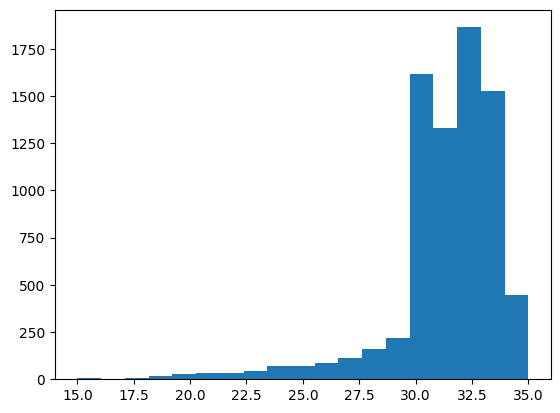

In [ ]:
plt.figure()
bins = np.linspace(15,35,20)
plt.hist(train_rows[train_rows['severity'] == 1]['albumin'],bins=bins)
plt.show()

## Resultat: 

hypoalbuminemi: <34 \
påtaglig hypoalbuminemi: < 30 \
grav hypoalbuminemi: <24